<a href="https://colab.research.google.com/github/karanmailme1/karanmailme1/blob/main/vision_agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Agents with smolagents


This notebook is part of the [Hugging Face Agents Course](https://www.hf.co/learn/agents-course), a free Course from beginner to expert, where you learn to build Agents.

![Agents course share](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/communication/share.png)

## Let's install the dependencies and login to our HF account to access the Inference API

If you haven't installed `smolagents` yet, you can do so by running the following command:

In [1]:
!pip install smolagents
!pip install ddgs -U
!pip install markdownify requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.4/145.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 70.8 MB/s eta 0:00:00
  Attempting uninstall: lxml
    Found existing installation: lxml 5.4.0
    Uninstalling lxml-5.4.0:
      Successfully uninstalled lxml-5.4.0


Let's also login to the Hugging Face Hub to have access to the Inference API.

In [3]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')

# this works

from smolagents import OpenAIServerModel

model = OpenAIServerModel(
    model_id="gemini-2.0-flash-lite",
    # Google Gemini OpenAI-compatible API base URL
    api_base="https://generativelanguage.googleapis.com/v1beta/openai/",
    api_key=GEMINI_API_KEY,
    #provider="together",
    max_tokens=8096,
)

In [2]:
from huggingface_hub import notebook_login

notebook_login()

## Providing Images at the Start of the Agent's Execution

In this approach, images are passed to the agent at the start and stored as `task_images` alongside the task prompt. The agent then processes these images throughout its execution.  

Consider the case where Alfred wants to verify the identities of the superheroes attending the party. He already has a dataset of images from previous parties with the names of the guests. Given a new visitor's image, the agent can compare it with the existing dataset and make a decision about letting them in.  

In this case, a guest is trying to enter, and Alfred suspects that this visitor might be The Joker impersonating Wonder Woman. Alfred needs to verify their identity to prevent anyone unwanted from entering.  

Let’s build the example. First, the images are loaded. In this case, we use images from Wikipedia to keep the example minimal, but imagine the possible use-cases!

In [4]:
from PIL import Image
import requests
from io import BytesIO

image_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/e/e8/The_Joker_at_Wax_Museum_Plus.jpg",
    "https://upload.wikimedia.org/wikipedia/en/9/98/Joker_%28DC_Comics_character%29.jpg"
]

images = []
for url in image_urls:
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"
    }
    response = requests.get(url,headers=headers)
    image = Image.open(BytesIO(response.content)).convert("RGB")
    images.append(image)

In [9]:
images

[<PIL.Image.Image image mode=RGB size=640x832>,
 <PIL.Image.Image image mode=RGB size=250x315>]

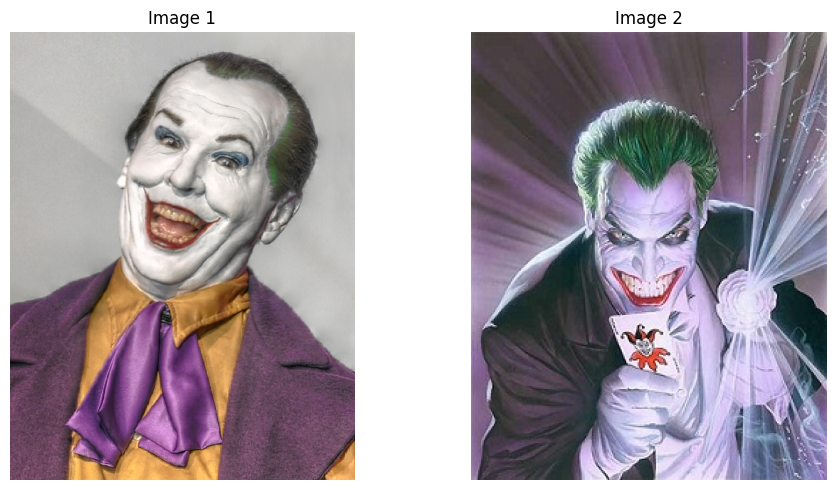

In [14]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display the first image in the first subplot
axes[0].imshow(images[0])
axes[0].set_title('Image 1')
axes[0].axis('off') # Hide axes ticks

# Display the second image in the second subplot
axes[1].imshow(images[1])
axes[1].set_title('Image 2')
axes[1].axis('off') # Hide axes ticks

plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show()

Now that we have the images, the agent will tell us wether the guests is actually a superhero (Wonder Woman) or a villian (The Joker).

In [5]:
from google.colab import userdata
import os
#os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [6]:
from smolagents import CodeAgent, OpenAIServerModel

#model = OpenAIServerModel(model_id="gpt-4o")

# Instantiate the agent
agent = CodeAgent(
    tools=[],
    model=model,
    max_steps=20,
    verbosity_level=2
)

response = agent.run(
    """
    Describe the costume and makeup that the comic character in these photos is wearing and return the description.
    Tell me if the guest is The Joker or Wonder Woman.
    """,
    images=images
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Describe the costume and makeup that the comic character in these photos is wearing and return the description. │
│     Tell me if the guest is The Joker or Wonder Woman.                                                          │
│                                                                                                                 │
╰─ OpenAIServerModel - gemini-2.0-flash-lite ─────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: The image shows a person with white face makeup, green hair, and a purple suit with a gold shirt and a    
purple tie. These are characteristics of The Joker. Let's confirm.                                                 
<code>                                                                                                             
final_answer("The character is The Joker. He is wearing white face makeup, green hair, a purple suit, a gold shirt 
and a purple tie.")                                                                                                
                                                                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("The character is The Joker. He is wearing white face makeup, green hair, a purple suit, a gold     
  shirt and a purple tie.")                                                                                        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The character is The Joker. He is wearing white face makeup, green hair, a purple suit, a gold shirt 
and a purple tie.

[Step 1: Duration 3.64 seconds| Input tokens: 2,596 | Output tokens: 76]

In [15]:
response

'The character is The Joker. He is wearing white face makeup, green hair, a purple suit, a gold shirt and a purple tie.'

In this case, the output reveals that the person is impersonating someone else, so we can prevent The Joker from entering the party!

## Providing Images with Dynamic Retrieval

This examples is provided as a `.py` file since it needs to be run locally since it'll browse the web. Go to the [Hugging Face Agents Course](https://www.hf.co/learn/agents-course) for more details.